
# Lufthansa Comparable Companies Valuation

## Python-Based M&A Valuation Project

This project performs a comparable companies analysis of Deutsche Lufthansa AG using selected European airline peers.

The analysis includes:
- Automated retrieval of historical share prices
- FX normalization
- LTM financial data construction and normalization
- Equity Value and Enterprise Value calculation
- EV/Revenue and EV/EBITDA trading multiples
- Peer-based implied valuation of Lufthansa
- Football Field valuation visualization

**Valuation Date:** 09 September 2026

**Target:** Deutsche Lufthansa AG

**Peer Group:** Air France-KLM, IAG, easyJet, Ryanair, Wizz Air

## 1. Imports & Configuration

The following libraries are used for data processing, numerical calculations, visualization, and historical market data retrieval.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
VALUATION_DATE = "2026-09-09"
TARGET_COMPANY = "Lufthansa"


## 2. Helper Functions

Reusable functions are used to retrieve historical share prices, calculate FX rates, and derive implied share prices from trading multiples.

In [3]:
def get_share_price(ticker, valuation_date):
    stock = yf.Ticker(ticker)

    history = stock.history(
        start=valuation_date,
        end=pd.to_datetime(valuation_date) + pd.Timedelta(days=1)
    )

    if history.empty:
        return np.nan

    return history["Close"].iloc[0]

In [4]:
def get_average_fx_rate(ticker, start_date, end_date):
    fx = yf.Ticker(ticker)

    history = fx.history(
        start=start_date,
        end=end_date
    )

    if history.empty:
        return np.nan

    return history["Close"].mean()

In [5]:
def calculate_implied_share_price(
    multiple,
    financial_metric,
    net_debt,
    shares_outstanding
):
    implied_ev = multiple * financial_metric
    implied_equity_value = implied_ev - net_debt
    implied_share_price = implied_equity_value / shares_outstanding

    return implied_share_price

## 3. Financial Data

Financial data is based on the latest available company reports as of the valuation date.

Where required, Last Twelve Months (LTM) figures are calculated as:

**LTM = Latest FY − Prior Comparable Period + Current Comparable Period**

For example, Lufthansa LTM Revenue is calculated as:

**€39,597m − €18,449m + €19,887m = €41,035m**

For companies with different reporting calendars, the latest available comparable financial period is used.

In [6]:
raw_financials = pd.DataFrame({
    "Company": [
        "Lufthansa",
        "Air France-KLM",
        "IAG",
        "easyJet",
        "Ryanair",
        "Wizz Air"
    ],

    "LTM_Revenue": [
        41035.0,
        34149.0,
        33371.0,
        10526.0,
        15590.8,
        5770.6
    ],

    "LTM_EBITDA": [
        4028.0,
        5204.0,
        7640.0,
        1317.0,
        3483.5,
        1165.5
    ],

    "Net_Debt": [
        6697.0,
        8376.0,
        4692.0,
        -434.0,
        -2700.0,
        5134.5
    ],

    "Financial_Date": pd.to_datetime([
        "2026-06-30",
        "2026-06-30",
        "2026-06-30",
        "2026-03-31",
        "2026-06-30",
        "2026-06-30"
    ]),

    "Financial_Currency": [
        "EUR",
        "EUR",
        "EUR",
        "GBP",
        "EUR",
        "EUR"
    ]
})


In [7]:
raw_financials[
    [
        "Company",
        "LTM_Revenue",
        "LTM_EBITDA",
        "Net_Debt",
        "Financial_Date",
        "Financial_Currency"
    ]
]

,Company,LTM_Revenue,LTM_EBITDA,Net_Debt,Financial_Date,Financial_Currency
0,Lufthansa,41035.0,4028.0,6697.0,2026-06-30,EUR
1,Air France-KLM,34149.0,5204.0,8376.0,2026-06-30,EUR
2,IAG,33371.0,7640.0,4692.0,2026-06-30,EUR
3,easyJet,10526.0,1317.0,-434.0,2026-03-31,GBP
4,Ryanair,15590.8,3483.5,-2700.0,2026-06-30,EUR
5,Wizz Air,5770.6,1165.5,5134.5,2026-06-30,EUR


## 4. Market Data

Market data is used to determine the equity value of the target company and its peer group as of the valuation date.

The dataset contains each company's ticker symbol, trading currency, and shares outstanding. Historical closing share prices are retrieved automatically using `yfinance` as of 9 September 2026.

For companies listed in the United Kingdom, share prices quoted in GBp (pence sterling) are first converted into GBP and subsequently translated into EUR using the GBP/EUR exchange rate on the valuation date.

The normalized EUR share prices are then multiplied by shares outstanding to derive each company's equity value.


In [8]:
market_data = pd.DataFrame({
    "Company": [
        "Lufthansa",
        "Air France-KLM",
        "IAG",
        "easyJet",
        "Ryanair",
        "Wizz Air"
    ],

    "Ticker": [
        "LHA.DE",
        "AF.PA",
        "IAG.L",
        "EZJ.L",
        "RYA.IR",
        "WIZZ.L"
    ],

    "Price_Currency": [
        "EUR",
        "EUR",
        "GBp",
        "GBp",
        "EUR",
        "GBp"
    ],

    "Shares_Outstanding": [
        1202.082895,
        262.769869,
        4611.669527,
        758.010025,
        1037.578393,
        103.390000
    ]
})


In [9]:
# Retrieve historical share prices for the valuation date

market_data["Share_Price_Local"] = market_data["Ticker"].apply(
    lambda ticker: get_share_price(ticker, VALUATION_DATE)
)

market_data[
    ["Company", "Ticker", "Share_Price_Local", "Price_Currency"]
]

,Company,Ticker,Share_Price_Local,Price_Currency
0,Lufthansa,LHA.DE,7.710000,EUR
1,Air France-KLM,AF.PA,11.585000,EUR
2,IAG,IAG.L,415.100006,GBp
3,easyJet,EZJ.L,668.200012,GBp
4,Ryanair,RYA.IR,22.600000,EUR
5,Wizz Air,WIZZ.L,1014.000000,GBp


In [10]:
# Normalize GBp share prices to GBP

market_data["Share_Price_Normalized"] = np.where(
    market_data["Price_Currency"] == "GBp",
    market_data["Share_Price_Local"] / 100,
    market_data["Share_Price_Local"]
)

In [11]:
gbp_eur_valuation = get_share_price("GBPEUR=X", VALUATION_DATE)

print(f"GBP/EUR at valuation date: {gbp_eur_valuation:.4f}")

GBP/EUR at valuation date: 1.1647


In [12]:
valuation_df = pd.merge(
    raw_financials,
    market_data,
    on="Company",
    how="left"
)

valuation_df

,Company,LTM_Revenue,LTM_EBITDA,Net_Debt,Financial_Date,Financial_Currency,Ticker,Price_Currency,Shares_Outstanding,Share_Price_Local,Share_Price_Normalized
0,Lufthansa,41035.0,4028.0,6697.0,2026-06-30,EUR,LHA.DE,EUR,1202.082895,7.710000,7.710
1,Air France-KLM,34149.0,5204.0,8376.0,2026-06-30,EUR,AF.PA,EUR,262.769869,11.585000,11.585
2,IAG,33371.0,7640.0,4692.0,2026-06-30,EUR,IAG.L,GBp,4611.669527,415.100006,4.151
3,easyJet,10526.0,1317.0,-434.0,2026-03-31,GBP,EZJ.L,GBp,758.010025,668.200012,6.682
4,Ryanair,15590.8,3483.5,-2700.0,2026-06-30,EUR,RYA.IR,EUR,1037.578393,22.600000,22.600
5,Wizz Air,5770.6,1165.5,5134.5,2026-06-30,EUR,WIZZ.L,GBp,103.390000,1014.000000,10.140


In [13]:
valuation_df["Share_Price_FX_to_EUR"] = np.where(
    valuation_df["Price_Currency"] == "GBp",
    gbp_eur_valuation,
    1.0
)

In [14]:
valuation_df["Share_Price_EUR"] = (
    valuation_df["Share_Price_Normalized"]
    * valuation_df["Share_Price_FX_to_EUR"]
)

In [15]:
easyjet_ltm_fx = get_average_fx_rate(
    "GBPEUR=X",
    "2025-04-01",
    "2026-04-01"
)

In [16]:
easyjet_balance_sheet_fx = get_share_price(
    "GBPEUR=X",
    "2026-03-31"
)

In [17]:
valuation_df["LTM_Revenue_EUR"] = valuation_df["LTM_Revenue"].astype(float)
valuation_df["LTM_EBITDA_EUR"] = valuation_df["LTM_EBITDA"].astype(float)
valuation_df["Net_Debt_EUR"] = valuation_df["Net_Debt"].astype(float)

In [18]:
easyjet_mask = valuation_df["Company"] == "easyJet"

valuation_df.loc[easyjet_mask, "LTM_Revenue_EUR"] *= easyjet_ltm_fx
valuation_df.loc[easyjet_mask, "LTM_EBITDA_EUR"] *= easyjet_ltm_fx
valuation_df.loc[easyjet_mask, "Net_Debt_EUR"] *= easyjet_balance_sheet_fx

In [19]:
valuation_df["Equity_Value"] = (
    valuation_df["Share_Price_EUR"]
    * valuation_df["Shares_Outstanding"]
)

In [20]:
valuation_df["Enterprise_Value"] = (
    valuation_df["Equity_Value"]
    + valuation_df["Net_Debt_EUR"]
)

In [21]:
# Calculate profitability and trading multiples

valuation_df["EBITDA_Margin"] = (
    valuation_df["LTM_EBITDA_EUR"]
    / valuation_df["LTM_Revenue_EUR"]
)

valuation_df["EV_Revenue"] = (
    valuation_df["Enterprise_Value"]
    / valuation_df["LTM_Revenue_EUR"]
)

valuation_df["EV_EBITDA"] = (
    valuation_df["Enterprise_Value"]
    / valuation_df["LTM_EBITDA_EUR"]
)

In [22]:
# FINAL VALUATION ANALYSIS

# 1. Classify airlines by business model

business_model_map = {
    "Lufthansa": "Network Carrier",
    "Air France-KLM": "Network Carrier",
    "IAG": "Network Carrier",
    "easyJet": "Low-Cost Carrier",
    "Ryanair": "Low-Cost Carrier",
    "Wizz Air": "Low-Cost Carrier"
}

valuation_df["Business_Model"] = (
    valuation_df["Company"].map(business_model_map)
)


# 2. Separate target company and peers

target = valuation_df[
    valuation_df["Company"] == TARGET_COMPANY
].copy()

peers = valuation_df[
    valuation_df["Company"] != TARGET_COMPANY
].copy()


# 3. Extract Lufthansa valuation inputs

target_revenue = target["LTM_Revenue_EUR"].iloc[0]
target_ebitda = target["LTM_EBITDA_EUR"].iloc[0]
target_net_debt = target["Net_Debt_EUR"].iloc[0]
target_shares = target["Shares_Outstanding"].iloc[0]
target_share_price = target["Share_Price_EUR"].iloc[0]


# 4. Build trading comparables table

comps_table = valuation_df[
    [
        "Company",
        "Business_Model",
        "LTM_Revenue_EUR",
        "LTM_EBITDA_EUR",
        "EBITDA_Margin",
        "Equity_Value",
        "Net_Debt_EUR",
        "Enterprise_Value",
        "EV_Revenue",
        "EV_EBITDA"
    ]
].copy()

comps_table = comps_table.rename(columns={
    "Business_Model": "Business Model",
    "LTM_Revenue_EUR": "LTM Revenue",
    "LTM_EBITDA_EUR": "LTM EBITDA",
    "EBITDA_Margin": "EBITDA Margin",
    "Equity_Value": "Equity Value",
    "Net_Debt_EUR": "Net Debt",
    "Enterprise_Value": "Enterprise Value",
    "EV_Revenue": "EV / Revenue",
    "EV_EBITDA": "EV / EBITDA"
})


# 5. Calculate peer statistics

peer_stats = pd.DataFrame({
    "Statistic": [
        "25th Percentile",
        "Median",
        "75th Percentile"
    ],

    "EV_Revenue": [
        peers["EV_Revenue"].quantile(0.25),
        peers["EV_Revenue"].median(),
        peers["EV_Revenue"].quantile(0.75)
    ],

    "EV_EBITDA": [
        peers["EV_EBITDA"].quantile(0.25),
        peers["EV_EBITDA"].median(),
        peers["EV_EBITDA"].quantile(0.75)
    ]
})

peer_stats

,Statistic,EV_Revenue,EV_EBITDA
0,25th Percentile,0.443645,3.532448
1,Median,0.808723,3.545791
2,75th Percentile,1.101366,5.453060


In [23]:
# 6. Extract peer valuation statistics

p25_stats = peer_stats.loc[
    peer_stats["Statistic"] == "25th Percentile"
].iloc[0]

median_stats = peer_stats.loc[
    peer_stats["Statistic"] == "Median"
].iloc[0]

p75_stats = peer_stats.loc[
    peer_stats["Statistic"] == "75th Percentile"
].iloc[0]


# 7. Calculate implied Lufthansa share-price ranges

valuation_results = pd.DataFrame({
    "Method": [
        "EV/Revenue",
        "EV/EBITDA"
    ],

    "Low": [
        calculate_implied_share_price(
            p25_stats["EV_Revenue"],
            target_revenue,
            target_net_debt,
            target_shares
        ),
        calculate_implied_share_price(
            p25_stats["EV_EBITDA"],
            target_ebitda,
            target_net_debt,
            target_shares
        )
    ],

    "Median": [
        calculate_implied_share_price(
            median_stats["EV_Revenue"],
            target_revenue,
            target_net_debt,
            target_shares
        ),
        calculate_implied_share_price(
            median_stats["EV_EBITDA"],
            target_ebitda,
            target_net_debt,
            target_shares
        )
    ],

    "High": [
        calculate_implied_share_price(
            p75_stats["EV_Revenue"],
            target_revenue,
            target_net_debt,
            target_shares
        ),
        calculate_implied_share_price(
            p75_stats["EV_EBITDA"],
            target_ebitda,
            target_net_debt,
            target_shares
        )
    ]
})

valuation_results["Low_Upside_Downside"] = (
    valuation_results["Low"] / target_share_price - 1
)

valuation_results["Median_Upside_Downside"] = (
    valuation_results["Median"] / target_share_price - 1
)

valuation_results["High_Upside_Downside"] = (
    valuation_results["High"] / target_share_price - 1
)

valuation_results.round(2)

,Method,Low,Median,High,Low_Upside_Downside,Median_Upside_Downside,High_Upside_Downside
0,EV/Revenue,9.57,22.04,32.03,0.24,1.86,3.15
1,EV/EBITDA,6.27,6.31,12.70,-0.19,-0.18,0.65


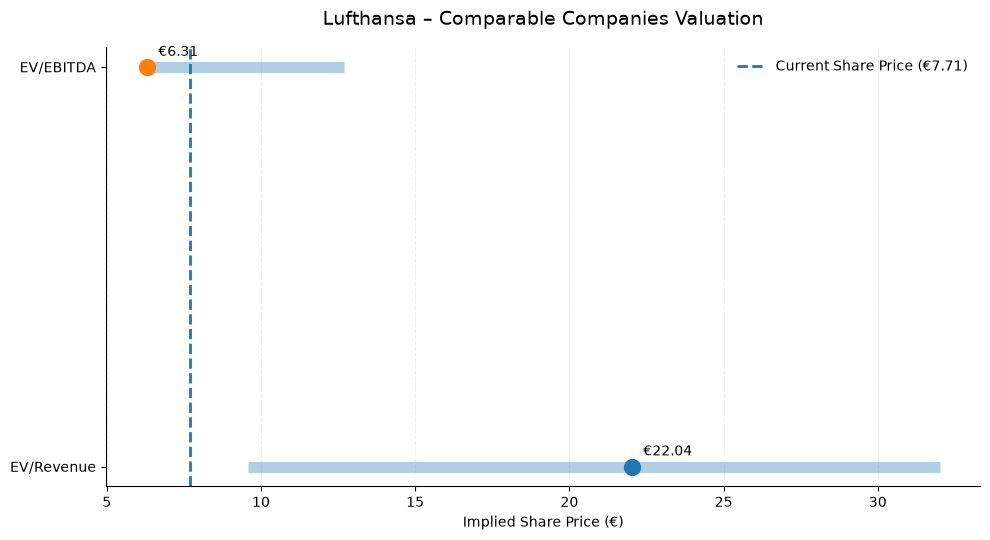

In [24]:
# 8. Football Field valuation chart

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, row in valuation_results.iterrows():

    ax.hlines(
        y=i,
        xmin=row["Low"],
        xmax=row["High"],
        linewidth=8,
        alpha=0.35
    )

    ax.scatter(
        row["Median"],
        i,
        s=130,
        zorder=3
    )

    ax.annotate(
        f'€{row["Median"]:.2f}',
        xy=(row["Median"], i),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

ax.axvline(
    target_share_price,
    linestyle="--",
    linewidth=2,
    label=f"Current Share Price (€{target_share_price:.2f})"
)

ax.set_yticks(range(len(valuation_results)))
ax.set_yticklabels(valuation_results["Method"])

ax.set_xlabel("Implied Share Price (€)")

ax.set_title(
    f"{TARGET_COMPANY} – Comparable Companies Valuation",
    fontsize=14,
    pad=16
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.savefig(
    "../outputs/football_field.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# 9. Peer-group analysis by business model

peers_only = valuation_df[
    valuation_df["Company"] != TARGET_COMPANY
].copy()

peer_group_stats = (
    peers_only
    .groupby("Business_Model")
    .agg(
        Companies=("Company", "count"),
        Median_EBITDA_Margin=("EBITDA_Margin", "median"),
        Median_EV_Revenue=("EV_Revenue", "median"),
        Median_EV_EBITDA=("EV_EBITDA", "median")
    )
    .reset_index()
)

peer_group_stats.round(2)

,Business_Model,Companies,Median_EBITDA_Margin,Median_EV_Revenue,Median_EV_EBITDA
0,Low-Cost Carrier,3,0.20,1.10,5.45
1,Network Carrier,2,0.19,0.57,2.86


In [26]:
# 10. Calculate EV/EBITDA valuation by peer group

all_peers_multiple = peers_only["EV_EBITDA"].median()

network_multiple = peer_group_stats.loc[
    peer_group_stats["Business_Model"] == "Network Carrier",
    "Median_EV_EBITDA"
].iloc[0]

low_cost_multiple = peer_group_stats.loc[
    peer_group_stats["Business_Model"] == "Low-Cost Carrier",
    "Median_EV_EBITDA"
].iloc[0]


peer_group_valuation = pd.DataFrame({
    "Valuation_Basis": [
        "All Peers",
        "Network Carriers",
        "Low-Cost Carriers"
    ],

    "EV_EBITDA_Multiple": [
        all_peers_multiple,
        network_multiple,
        low_cost_multiple
    ]
})


peer_group_valuation["Implied_Share_Price"] = (
    peer_group_valuation["EV_EBITDA_Multiple"]
    .apply(
        lambda multiple: calculate_implied_share_price(
            multiple=multiple,
            financial_metric=target_ebitda,
            net_debt=target_net_debt,
            shares_outstanding=target_shares
        )
    )
)


peer_group_valuation["Upside_Downside"] = (
    peer_group_valuation["Implied_Share_Price"]
    / target_share_price
    - 1
)

peer_group_valuation.round(2)

,Valuation_Basis,EV_EBITDA_Multiple,Implied_Share_Price,Upside_Downside
0,All Peers,3.55,6.31,-0.18
1,Network Carriers,2.86,4.02,-0.48
2,Low-Cost Carriers,5.45,12.70,0.65


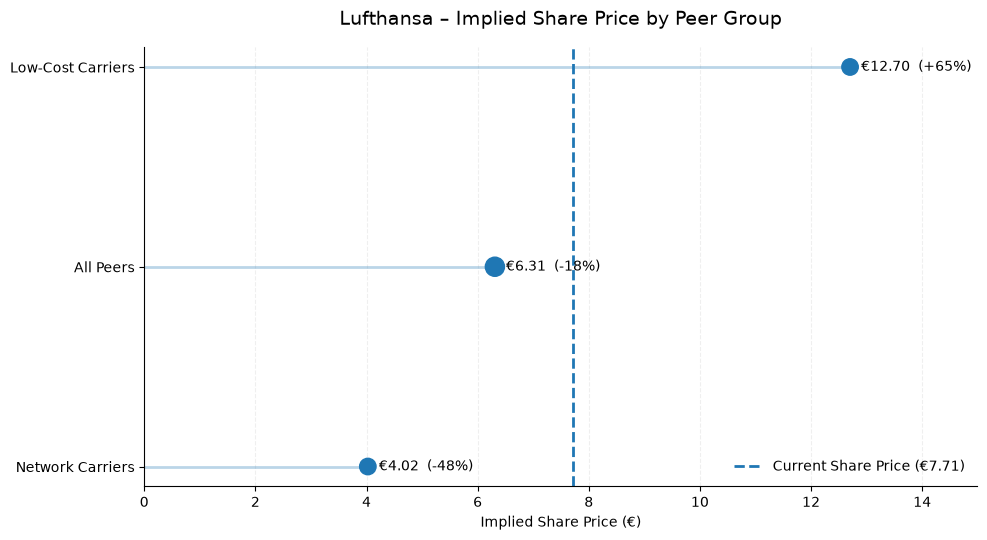

In [27]:
# 11. Peer-group valuation chart

plot_df = (
    peer_group_valuation
    .sort_values("Implied_Share_Price", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

y_positions = np.arange(len(plot_df))

ax.hlines(
    y=y_positions,
    xmin=0,
    xmax=plot_df["Implied_Share_Price"],
    linewidth=2,
    alpha=0.30
)

marker_sizes = [
    190 if basis == "All Peers" else 140
    for basis in plot_df["Valuation_Basis"]
]

ax.scatter(
    plot_df["Implied_Share_Price"],
    y_positions,
    s=marker_sizes,
    zorder=3
)

ax.axvline(
    target_share_price,
    linestyle="--",
    linewidth=2,
    label=f"Current Share Price (€{target_share_price:.2f})"
)

for i, row in plot_df.iterrows():

    ax.annotate(
        f'€{row["Implied_Share_Price"]:.2f}  '
        f'({row["Upside_Downside"]:+.0%})',
        xy=(row["Implied_Share_Price"], i),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["Valuation_Basis"])

ax.set_xlabel("Implied Share Price (€)")

ax.set_title(
    f"{TARGET_COMPANY} – Implied Share Price by Peer Group",
    fontsize=14,
    pad=16
)

max_price = max(
    plot_df["Implied_Share_Price"].max(),
    target_share_price
)

ax.set_xlim(
    0,
    max_price * 1.18
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.savefig(
    "../outputs/peer_group_valuation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()